<a href="https://colab.research.google.com/github/AliSaeidan4390/Water-Quality/blob/main/Ali_Saeidan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdflib

In [ ]:
import rdflib
import pydot
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph
import librosa
import matplotlib.pyplot as plt
import networkx as nx
from rdflib import Graph, Namespace, Literal, RDF, RDFS, URIRef

Create a new RDF graph

In [ ]:
g = Graph()

Define namespaces

In [ ]:
EX = Namespace("http://example#")

Bind prefixes

In [ ]:
g.bind("ex", EX)

Define classes

In [ ]:
g.add((EX.Drug, RDF.type, RDFS.Class))
g.add((EX.Medicine, RDF.type, RDFS.Class))
g.add((EX.Medicine, RDFS.subClassOf, EX.Drug))
g.add((EX.Protein, RDF.type, RDFS.Class))
g.add((EX.ActiveIngredient, RDF.type, RDFS.Class))
g.add((EX.Effect, RDF.type, RDFS.Class))
g.add((EX.SideEffect, RDF.type, RDFS.Class))
g.add((EX.PrimaryEffect, RDF.type, RDFS.Class))
g.add((EX.Interaction, RDF.type, RDFS.Class))
g.add((EX.DrugDrugInteraction, RDF.type, RDFS.Class))
g.add((EX.DrugProteinInteraction, RDF.type, RDFS.Class))
g.add((EX.Approval, RDF.type, RDFS.Class))

<Graph identifier=N34f9722603f649a58a872b592ab502c6 (<class 'rdflib.graph.Graph'>)>

Define properties

In [ ]:
g.add((EX.hasCode, RDF.type, RDF.Property))
g.add((EX.hasName, RDF.type, RDF.Property))
g.add((EX.hasDescription, RDF.type, RDF.Property))
g.add((EX.hasClassification, RDF.type, RDF.Property))
g.add((EX.hasActiveIngredient, RDF.type, RDF.Property))
g.add((EX.hasHalfLife, RDF.type, RDF.Property))
g.add((EX.targetsProtein, RDF.type, RDF.Property))
g.add((EX.hasEffect, RDF.type, RDF.Property))
g.add((EX.causesSideEffect, RDF.type, RDF.Property))
g.add((EX.hasInteraction, RDF.type, RDF.Property))
g.add((EX.isApprovedBy, RDF.type, RDF.Property))
g.add((EX.hasApprovalStatus, RDF.type, RDF.Property))
g.add((EX.hasApprovalDate, RDF.type, RDF.Property))

<Graph identifier=N34f9722603f649a58a872b592ab502c6 (<class 'rdflib.graph.Graph'>)>

Example individuals (instances)

In [ ]:
aspirin = URIRef(EX.Aspirin)
fda = URIRef(EX.FDA)
cox1 = URIRef(EX.COX1)

Adding example instances

In [ ]:
g.add((aspirin, RDF.type, EX.Drug))
g.add((aspirin, EX.hasName, Literal("Aspirin")))
g.add((aspirin, EX.hasCode, Literal("D00123")))
g.add((aspirin, EX.hasActiveIngredient, Literal("Acetylsalicylic Acid")))
g.add((aspirin, EX.hasClassification, Literal("Nonsteroidal anti-inflammatory drugs (NSAIDs)")))
g.add((aspirin, EX.targetsProtein, cox1))
g.add((aspirin, EX.hasEffect, Literal("Pain relief, anti-inflammatory")))
g.add((aspirin, EX.causesSideEffect, Literal("Gastrointestinal discomfort")))

<Graph identifier=N34f9722603f649a58a872b592ab502c6 (<class 'rdflib.graph.Graph'>)>

Example of approval information

In [ ]:
g.add((aspirin, EX.isApprovedBy, fda))
g.add((aspirin, EX.hasApprovalStatus, Literal("Approved")))
g.add((aspirin, EX.hasApprovalDate, Literal("1899-01-01")))

<Graph identifier=N34f9722603f649a58a872b592ab502c6 (<class 'rdflib.graph.Graph'>)>

Serialize and print RDF graph in Turtle format

Convert the RDF graph into a NetworkX graph

In [ ]:
g.serialize(destination="output2.xml", format='xml')

<Graph identifier=N34f9722603f649a58a872b592ab502c6 (<class 'rdflib.graph.Graph'>)>

Convert the RDF graph into a NetworkX graph

In [ ]:
nx_graph = rdflib_to_networkx_graph(g)

Draw the graph using Matplotlib and NetworkX

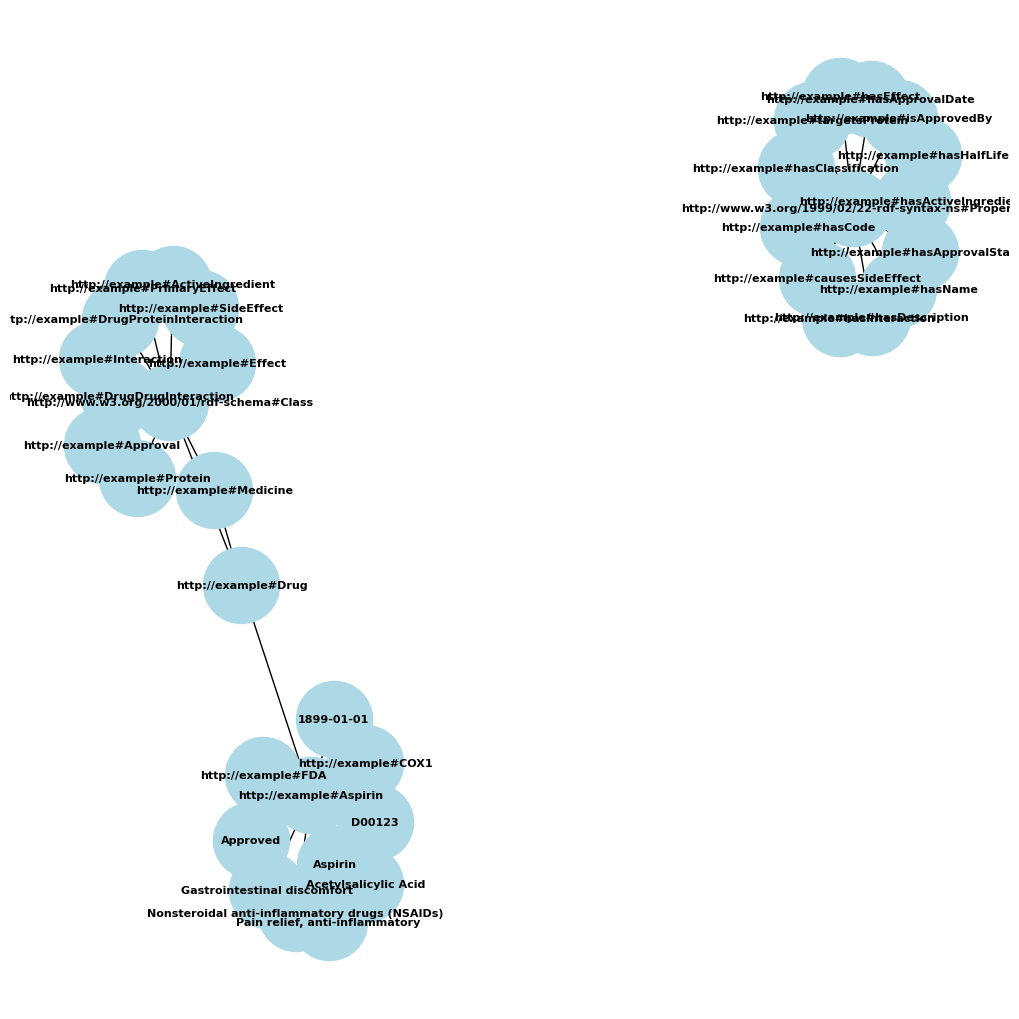

In [ ]:
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(nx_graph)
nx.draw(nx_graph, pos, with_labels=True, node_color='lightblue', font_size=8, font_weight='bold', node_size=3000)
plt.show()